In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

In [21]:
# Generate the moons dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Convert to PyTorch tensors
# Ensure y is float for MSE loss
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Unsqueeze for MSE loss

# Print shapes
print("Shape of X_tensor:", X_tensor.shape)
print("Shape of y_tensor:", y_tensor.shape)

Shape of X_tensor: torch.Size([1000, 2])
Shape of y_tensor: torch.Size([1000, 1])


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: torch.Size([800, 2])
Shape of X_test: torch.Size([200, 2])
Shape of y_train: torch.Size([800, 1])
Shape of y_test: torch.Size([200, 1])


In [23]:
# Training the model
epochs = 1000
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train)
    # MSELoss expects target to be float and same shape as output
    loss = criterion(outputs, y_train)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.0036
Epoch [200/1000], Loss: 0.0030
Epoch [300/1000], Loss: 0.0026
Epoch [400/1000], Loss: 0.0022
Epoch [500/1000], Loss: 0.0020
Epoch [600/1000], Loss: 0.0018
Epoch [700/1000], Loss: 0.0016
Epoch [800/1000], Loss: 0.0015
Epoch [900/1000], Loss: 0.0013
Epoch [1000/1000], Loss: 0.0012


In [24]:
# Define the Neural Network
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 10) # Input layer (2 features) to hidden layer (10 neurons)
        self.relu = nn.ReLU()      # ReLU activation function
        self.fc2 = nn.Linear(10, 1)  # Hidden layer (10 neurons) to output layer (1 neuron)
        self.sigmoid = nn.Sigmoid() # Sigmoid activation for binary output

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x) # Apply sigmoid to the output
        return x

# Instantiate the model
model = SimpleNN()

# Define Loss function and Optimizer
criterion = nn.MSELoss()  # Mean Squared Error Loss for regression-like output
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam optimizer

In [25]:
# Evaluate the model on the test data
with torch.no_grad():  # Disable gradient calculation
    # Get predictions on the test set
    test_outputs = model(X_test)
    # Round predictions to get binary classification results (0 or 1)
    predicted_test = test_outputs.round()

# Calculate accuracy
# Compare rounded predictions with the actual test labels and calculate the mean
accuracy_test = (predicted_test == y_test).sum().item() / y_test.size(0)
print(f'Accuracy of the network on the test set: {accuracy_test:.4f}')

Accuracy of the network on the test set: 0.5000


/tmp/ipython-input-547162468.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
/tmp/ipython-input-547162468.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, h))


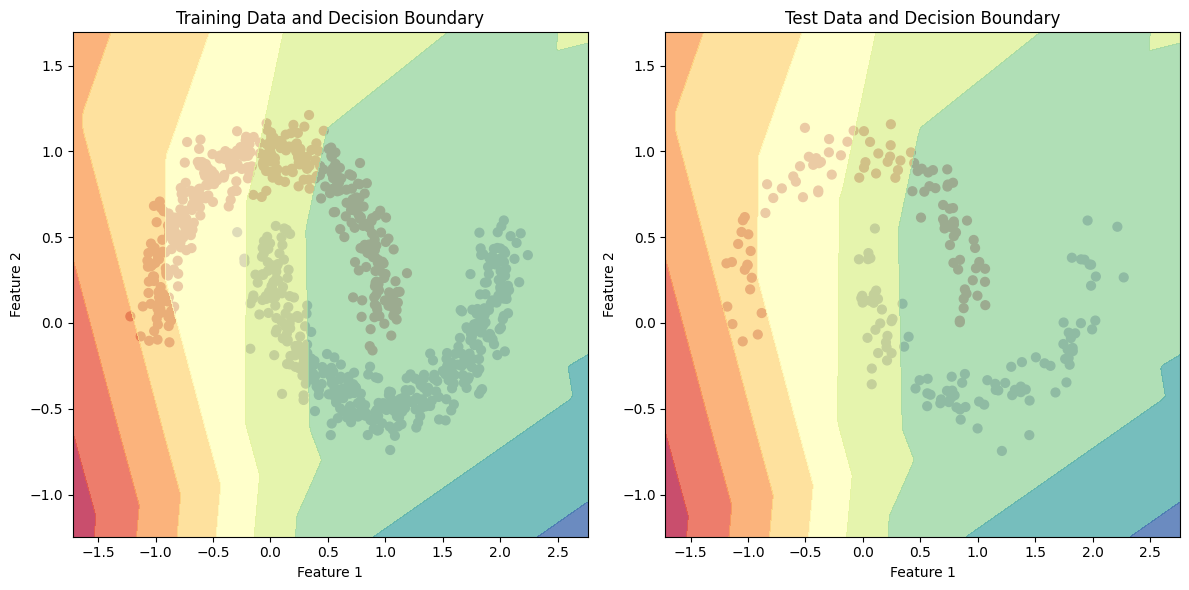

In [26]:
plt.figure(figsize=(12, 6))

# Plot the training data
plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.squeeze().detach().numpy(), s=40, cmap=plt.cm.Spectral)
plt.title("Training Data and Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Create a meshgrid
x_min, x_max = min(X_train[:, 0].min(), X_test[:, 0].min()) - .5, max(X_train[:, 0].max(), X_test[:, 0].max()) + .5
y_min, y_max = min(X_train[:, 1].min(), X_test[:, 1].min()) - .5, max(X_train[:, 1].max(), X_test[:, 1].max()) + .5
h = 0.02 # Meshgrid step size
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict the output for each point in the meshgrid
with torch.no_grad():
    Z = model(torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)).detach().numpy()

# Reshape the predictions
Z = Z.reshape(xx.shape)

# Plot the decision boundary on training data plot
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)


# Plot the test data
plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.squeeze().detach().numpy(), s=40, cmap=plt.cm.Spectral)
plt.title("Test Data and Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Plot the decision boundary on test data plot
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

plt.tight_layout()
plt.show()

In [27]:
# Store training losses
training_losses = []

# Training the model
epochs = 1000
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train)
    # MSELoss expects target to be float and same shape as output
    loss = criterion(outputs, y_train)

    # Store loss
    training_losses.append(loss.item())

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [100/1000], Loss: 0.0656
Epoch [200/1000], Loss: 0.0333
Epoch [300/1000], Loss: 0.0112
Epoch [400/1000], Loss: 0.0060
Epoch [500/1000], Loss: 0.0040
Epoch [600/1000], Loss: 0.0029
Epoch [700/1000], Loss: 0.0022
Epoch [800/1000], Loss: 0.0018
Epoch [900/1000], Loss: 0.0014
Epoch [1000/1000], Loss: 0.0012


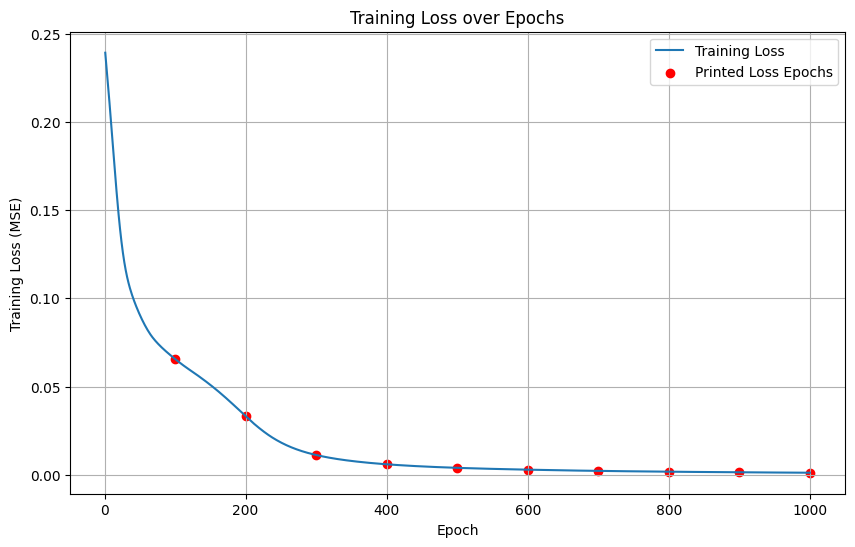

In [28]:
# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), training_losses, label='Training Loss')
# Add markers for the epochs where loss was printed for comparison
print_epochs = range(100, epochs + 1, 100)
plt.scatter(print_epochs, [training_losses[i - 1] for i in print_epochs], color='red', label='Printed Loss Epochs')
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.legend()
plt.show()